# Geometry, nonuniform mesh and enlarged cells
Run all cells from the project root or `notebooks/`, using the project `.venv` kernel.
This notebook prepares geometry and coefficients on the CPU; it does not run FDTD and needs no CUDA device.
The next notebook performs the GPU solve. See [solver/API guide](../docs/solver_api.md).

All plotted coordinates use the pulse-centre wavelength. Filled boundaries are continuous geometry;
mesh intersections, not the display raster, determine the conformal coefficients.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/fdtdmesh").is_dir())
sys.path.insert(0, str(ROOT / "src"))

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from fdtdmesh.cases import canonical_case
from fdtdmesh.constants import C0
from fdtdmesh.simulation import prepare

OUT = ROOT / "artifacts/notebooks"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})

In [3]:
SHAPE = "cylinder"  # cylinder, rectangle, pair, slot, empty
PPW = 16  # multiple of eight; increase after inspecting resolution
case, uniform = canonical_case(SHAPE, ppw=PPW)
_, graded = canonical_case(SHAPE, ppw=PPW, nonuniform=True)
lam = C0 / case.frequency
coeff, box, source, contour, options = prepare(case, graded)
print(f"Graded grid: {graded.Nx} x {graded.Ny} cells")
print(f"dt = {coeff.dt:.5g} s; enlarged pairs = {len(coeff.hx.pairs) + len(coeff.hy.pairs)}")
print(f"Earliest eligible convergence check: step {options['min_steps']}")

Graded grid: 96 x 96 cells
dt = 2.7505e-11 s; enlarged pairs = 44
Earliest eligible convergence check: step 1163


## Full domain and geometry detail
Dashed boxes mark TFSF and the scattered-field observation contour. Grey strips are PML.
The source line belongs to the auxiliary 1D incident solver; it is not a physical line radiator in the 2D field.
The zoom shows every grid line. `--graded`/`nonuniform=True` is a demonstration density, not a learned allocation.

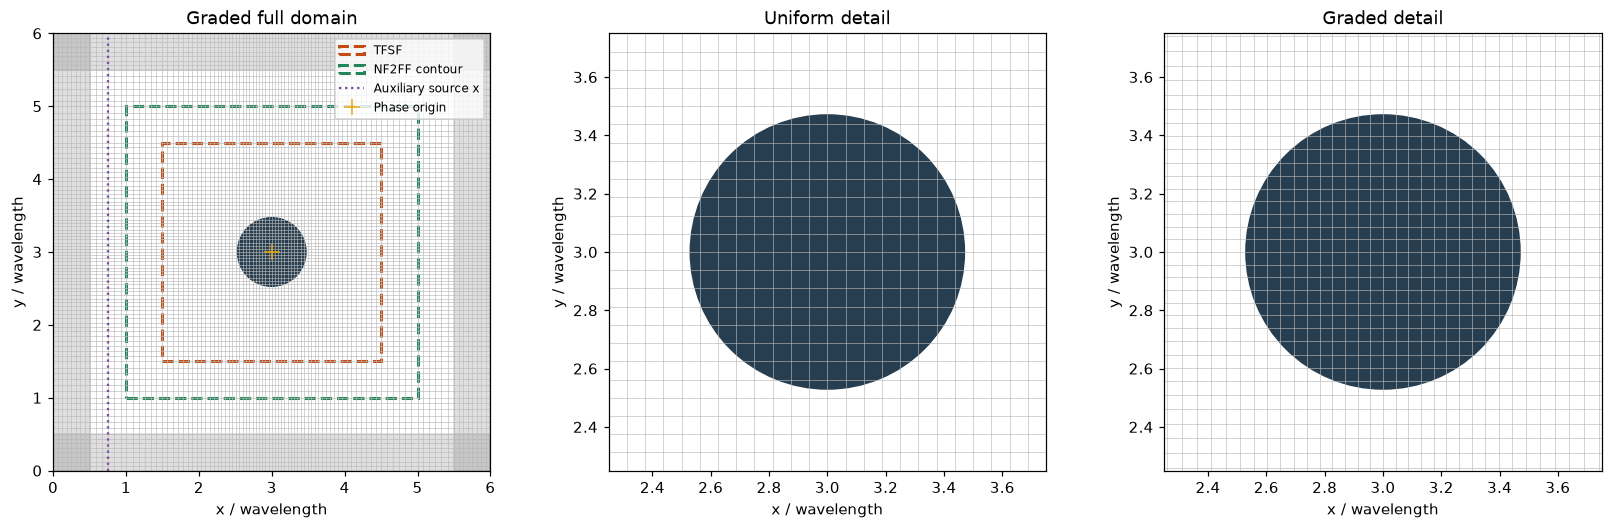

In [4]:
from matplotlib.patches import Circle, Polygon, Rectangle


def draw_geometry(ax, scene):
    for kind, metal, data in scene.primitives:
        color = "#273e50" if metal else "white"
        if kind == "circle":
            patch = Circle(
                np.array(data[:2]) / lam, data[2] / lam, facecolor=color, edgecolor=color
            )
        else:
            patch = Polygon(np.asarray(data) / lam, facecolor=color, edgecolor=color)
        ax.add_patch(patch)


def draw_mesh(ax, mesh):
    for x in mesh.x / lam:
        ax.axvline(x, color=".72", lw=0.4, zorder=2)
    for y in mesh.y / lam:
        ax.axhline(y, color=".72", lw=0.4, zorder=2)
    draw_geometry(ax, case.scene)
    ax.set(aspect="equal", xlabel="x / wavelength", ylabel="y / wavelength")


fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), constrained_layout=True)
for ax, mesh, title in zip(
    axes, [graded, uniform, graded], ["Graded full domain", "Uniform detail", "Graded detail"]
):
    draw_mesh(ax, mesh)
    ax.set_title(title)
    ax.set(
        xlim=(0, 6) if ax is axes[0] else (2.25, 3.75),
        ylim=(0, 6) if ax is axes[0] else (2.25, 3.75),
    )
ax = axes[0]
for lo, hi in [(0, 0.5), (5.5, 6)]:
    ax.axvspan(lo, hi, color=".5", alpha=0.25)
    ax.axhspan(lo, hi, color=".5", alpha=0.25)
for bounds, color, label in [
    (case.tfsf_box, "#c14b12", "TFSF"),
    (case.contour_box, "#23865a", "NF2FF contour"),
]:
    x0, x1, y0, y1 = np.asarray(bounds) / lam
    ax.add_patch(
        Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ls="--", ec=color, lw=2, label=label)
    )
ax.axvline(case.source_x / lam, color="#7b4da3", ls=":", label="Auxiliary source x")
ax.plot(*np.asarray(case.origin) / lam, "+", color="#e5aa13", ms=10, label="Phase origin")
ax.legend(fontsize=8, loc="upper right")
fig.savefig(OUT / "geometry_mesh.png", dpi=160)
plt.show()

## Exact cut-face locations and enlarged partners
Orange markers locate partially open magnetic faces. Each red segment joins a small face to the full-vacuum donor used by the enlarged-cell operator. Segment positions are the original Yee face centres; they do not move the PEC boundary. Both Hx and Hy pairs are shown.

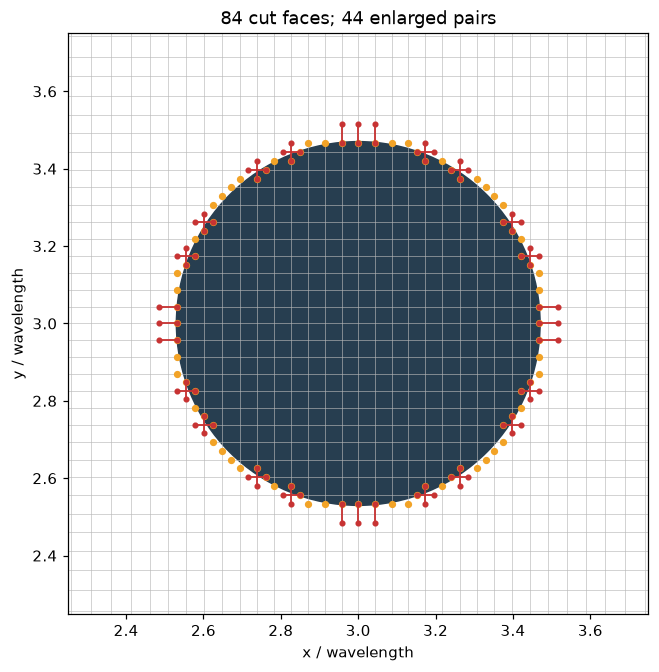

In [5]:
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
draw_mesh(ax, graded)
cut_count = 0
for axis, op in [(1, coeff.hx), (0, coeff.hy)]:
    if axis == 1:
        xx, yy = np.meshgrid(graded.x, (graded.y[:-1] + graded.y[1:]) / 2, indexing="ij")
        full = np.broadcast_to(np.diff(graded.y)[None, :], op.length.shape)
    else:
        xx, yy = np.meshgrid((graded.x[:-1] + graded.x[1:]) / 2, graded.y, indexing="ij")
        full = np.broadcast_to(np.diff(graded.x)[:, None], op.length.shape)
    cut = (op.length > 0) & (op.length < full * (1 - 1e-10))
    ax.scatter(xx[cut] / lam, yy[cut] / lam, c="#f2a327", s=14, zorder=5)
    cut_count += int(cut.sum())
    for a, b, borrowed in op.pairs:
        ax.plot(
            xx.ravel()[[a, b]] / lam,
            yy.ravel()[[a, b]] / lam,
            "o-",
            color="#c73333",
            ms=3,
            lw=1.2,
            zorder=6,
        )
ax.set(
    xlim=(2.25, 3.75),
    ylim=(2.25, 3.75),
    title=f"{cut_count} cut faces; {len(coeff.hx.pairs) + len(coeff.hy.pairs)} enlarged pairs",
)
fig.savefig(OUT / "conformal_pairs.png", dpi=160)
plt.show()

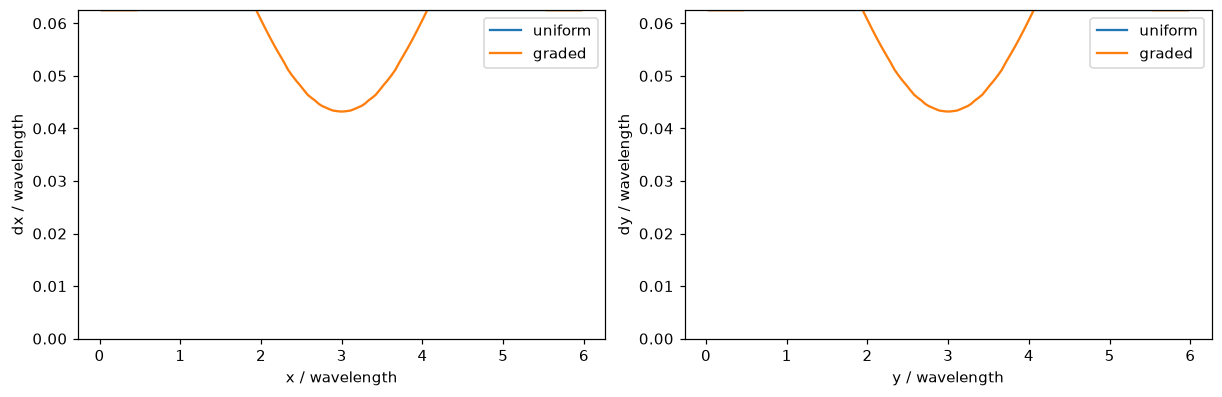

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)
for name, mesh in [("uniform", uniform), ("graded", graded)]:
    for ax, axis in zip(axes, ["x", "y"]):
        lines = getattr(mesh, axis)
        ax.plot((lines[:-1] + lines[1:]) / (2 * lam), np.diff(lines) / lam, label=name)
        ax.set(xlabel=f"{axis} / wavelength", ylabel=f"d{axis} / wavelength", ylim=(0, None))
        ax.legend()
plt.show()

## Changing geometry
Use `Scene2D.add_circle`, `add_rectangle`, or `add_polygon`; `pec=False` creates an ordered vacuum overlay.
Keep geometry inside TFSF with clearance. The solver rejects unrepresentable edge connectivity and missing donors.
Adding more cells does not guarantee a rotated corner is representable: some shapes require geometry anchors.
See the guide for custom geometry and density-mesh construction.